# EDA da Unidade Móvel Copacabana

Este notebook será usado para a análise exploratória individual da **Unidade Móvel Copacabana**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da Unidade Móvel é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da Unidade Móvel de Copacabana. Como o nome da Unidade Móvel pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [3]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_copacabana = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL COPACABANA"].copy()

print("Dimensoes da base da Unidade Movel Copacabana:", df_copacabana.shape)
display(df_copacabana.head())

Dimensoes da base da Unidade Movel Copacabana: (2786, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
350313,2016-08-02 17:30:00,UNIDADE MOVEL COPACABANA,0.0,22.90,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,-22.976488,-43.193708
350326,2016-08-02 18:30:00,UNIDADE MOVEL COPACABANA,0.0,23.35,74.82,3.47,NaN,NaN,NaN,NaN,11.59,NaN,25.0,-22.976488,-43.193708
350336,2016-08-02 19:30:00,UNIDADE MOVEL COPACABANA,0.0,23.05,75.03,3.83,NaN,0.38,NaN,NaN,8.67,NaN,10.0,-22.976488,-43.193708
350344,2016-08-02 20:30:00,UNIDADE MOVEL COPACABANA,0.0,22.88,73.28,4.58,NaN,0.22,NaN,NaN,13.27,NaN,11.0,-22.976488,-43.193708
350349,2016-08-02 21:30:00,UNIDADE MOVEL COPACABANA,0.0,22.35,76.88,4.93,NaN,0.09,NaN,NaN,23.34,NaN,8.0,-22.976488,-43.193708


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [5]:
df_copacabana["data"] = pd.to_datetime(df_copacabana["data"], errors="coerce")

timestamps_unicos = df_copacabana["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_copacabana),
            df_copacabana["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2016-08-02 17:30:00
1,ultima_medicao,2016-11-26 23:30:00
2,n_linhas,2786
3,anos_cobertos,1


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a Unidade Móvel tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [6]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 2791
Quantidade de timestamps observados: 2786
Quantidade de timestamps faltantes: 5


,data_faltante
0,2016-08-21 19:30:00
1,2016-08-21 20:30:00
2,2016-08-21 21:30:00
3,2016-08-21 22:30:00
4,2016-08-21 23:30:00


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2016,2791,2786,5,99.82


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2016-08,2016,8,703,698,5,99.29
1,2016-09,2016,9,720,720,0,100.00
2,2016-10,2016,10,744,744,0,100.00
3,2016-11,2016,11,624,624,0,100.00


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [7]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_copacabana.columns,
        "n_missing": df_copacabana.isna().sum().values,
        "missing_pct": (100 * df_copacabana.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 4


,coluna,n_missing,missing_pct
0,no,2786,100.0
1,no2,2786,100.0
2,nox,2786,100.0
3,pm10,2786,100.0


,coluna,n_missing,missing_pct
0,no,2786,100.00
1,no2,2786,100.00
2,nox,2786,100.00
3,pm10,2786,100.00
4,so2,1037,37.22
5,co,178,6.39
6,pm2_5,74,2.66
7,o3,67,2.40
8,temp,58,2.08
9,ur,47,1.69


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da estação.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [8]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_copacabana.columns]

df_copacabana_carac = df_copacabana.copy()
df_copacabana_carac["data"] = pd.to_datetime(df_copacabana_carac["data"], errors="coerce")
df_copacabana_carac["data_dia"] = df_copacabana_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_copacabana_carac[coluna] = pd.to_numeric(df_copacabana_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [9]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_copacabana_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,2742,44,1.58,0.07,0.00,0.46,0.00,0.00,0.00,12.00,14.15
1,temp,meteorologica,2728,58,2.08,23.30,23.10,2.64,21.57,24.65,16.48,35.78,0.81
2,ur,meteorologica,2739,47,1.69,71.40,72.12,11.99,64.60,79.62,21.77,94.42,-0.72
3,co,poluente,2608,178,6.39,0.31,0.23,0.31,0.11,0.40,0.00,2.58,2.64
4,no,poluente,0,2786,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,no2,poluente,0,2786,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nox,poluente,0,2786,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,o3,poluente,2719,67,2.40,22.00,19.32,16.95,8.25,32.47,0.00,86.63,0.78
8,pm10,poluente,0,2786,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pm2_5,poluente,2712,74,2.66,8.49,6.00,9.27,1.00,12.00,0.00,78.00,1.72


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [10]:
timestamps_carac = df_copacabana_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_copacabana_carac["data_dia"].min(), df_copacabana_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_copacabana_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_menos_de_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_4_ou_mais_faltantes": int((faltantes_por_dia >= 4).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_menos_de_4_faltantes,dias_com_4_ou_mais_faltantes
0,chuva,meteorologica,24,117,111,1,0.85,6
1,temp,meteorologica,24,117,105,6,5.13,6
2,ur,meteorologica,24,117,108,4,3.42,5
3,co,poluente,24,117,8,102,87.18,8
4,no,poluente,24,117,0,0,0.00,117
5,no2,poluente,24,117,0,0,0.00,117
6,nox,poluente,24,117,0,0,0.00,117
7,o3,poluente,24,117,101,10,8.55,7
8,pm10,poluente,24,117,0,0,0.00,117
9,pm2_5,poluente,24,117,89,23,19.66,6


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


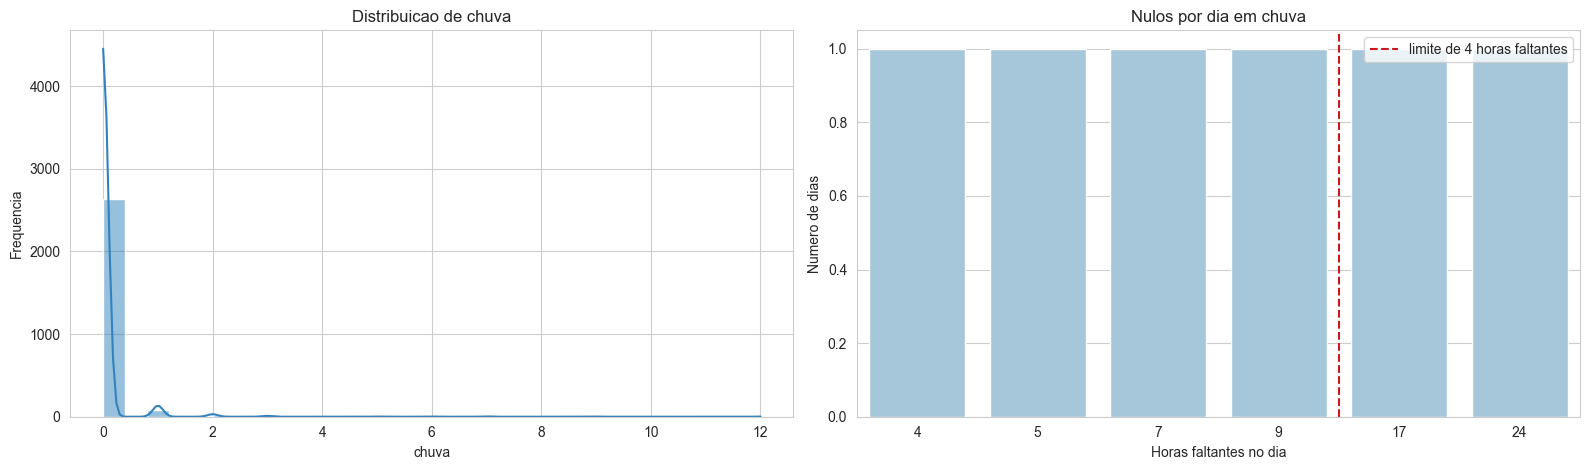

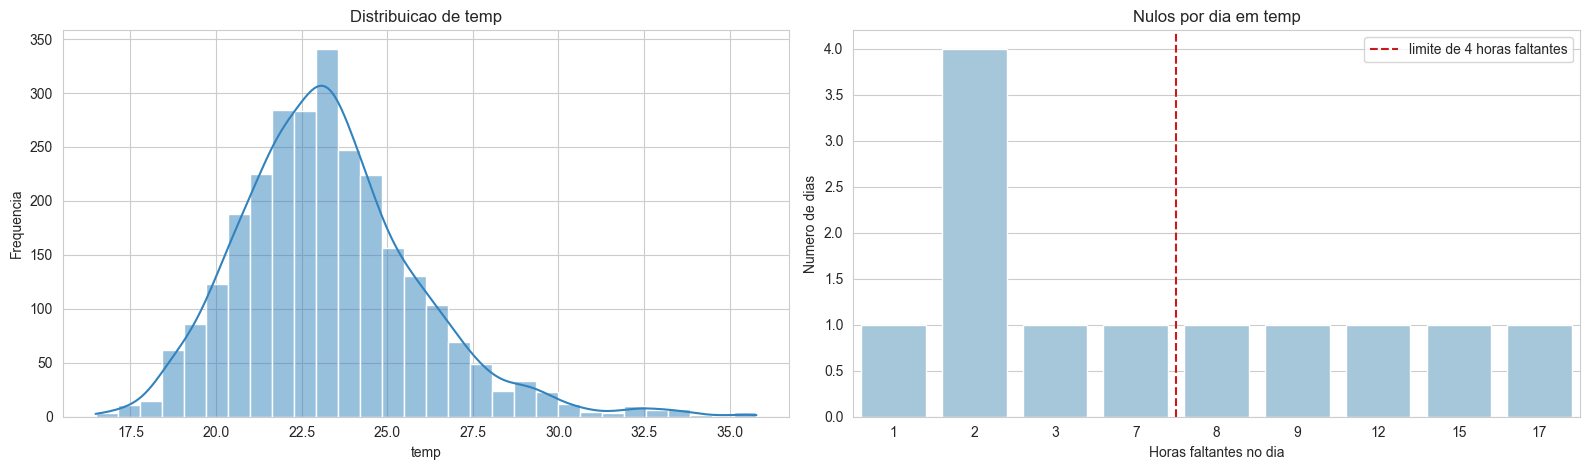

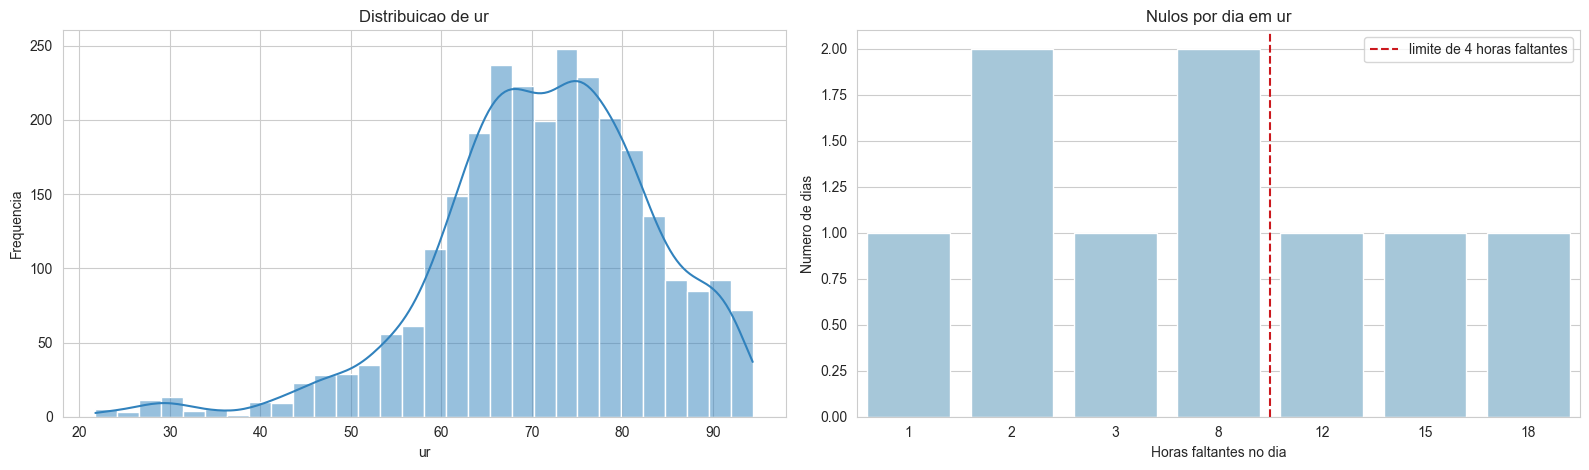

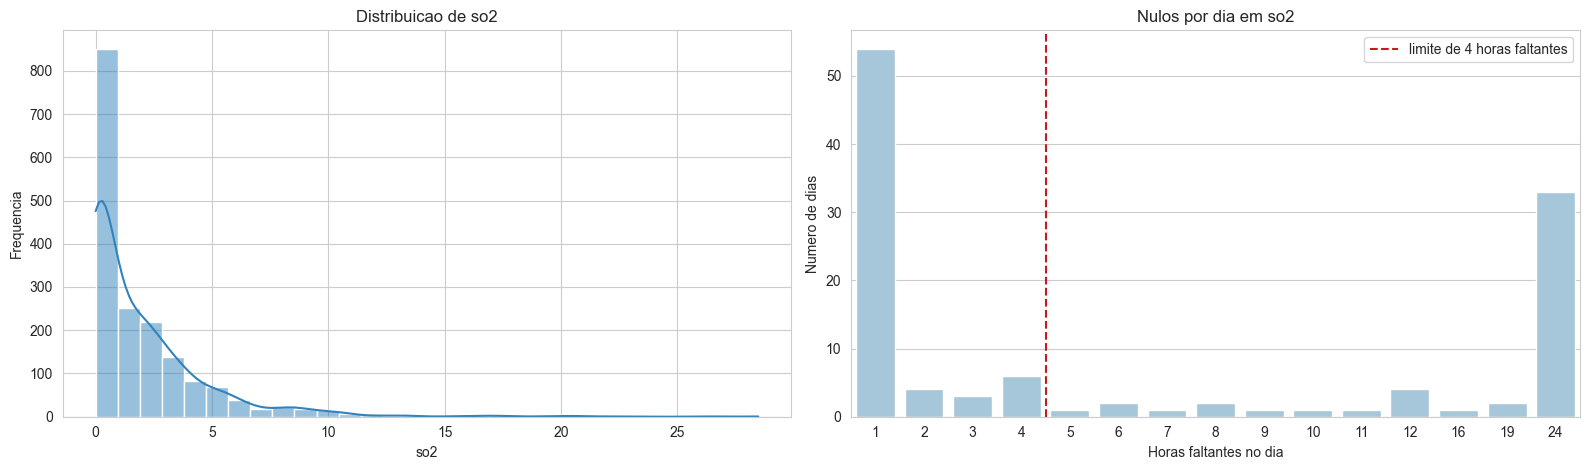

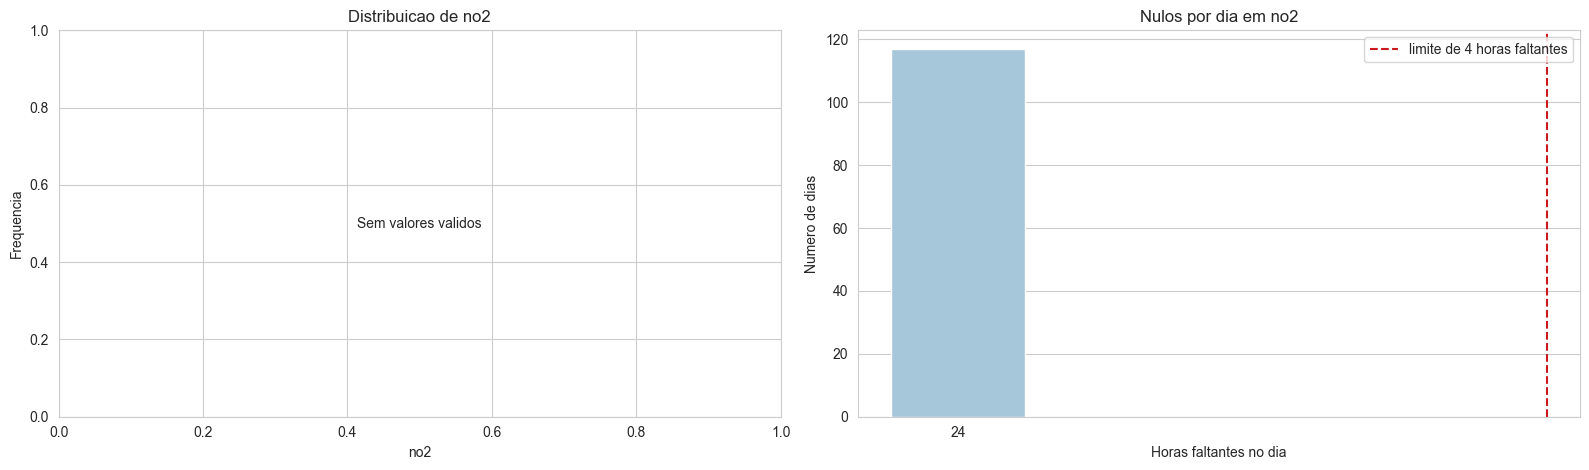

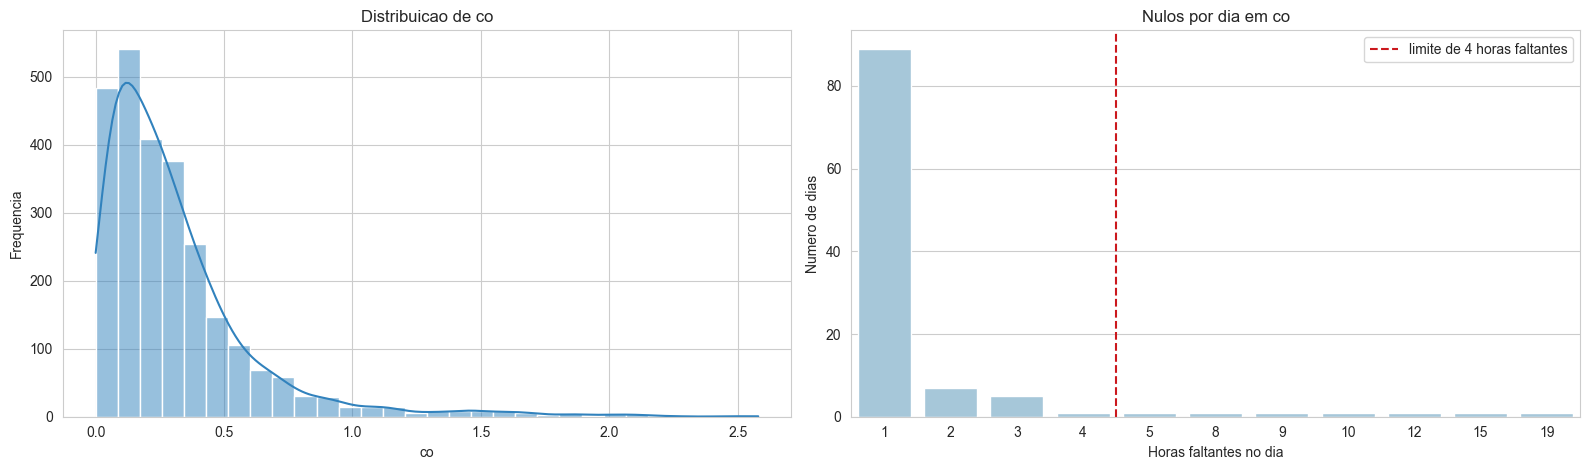

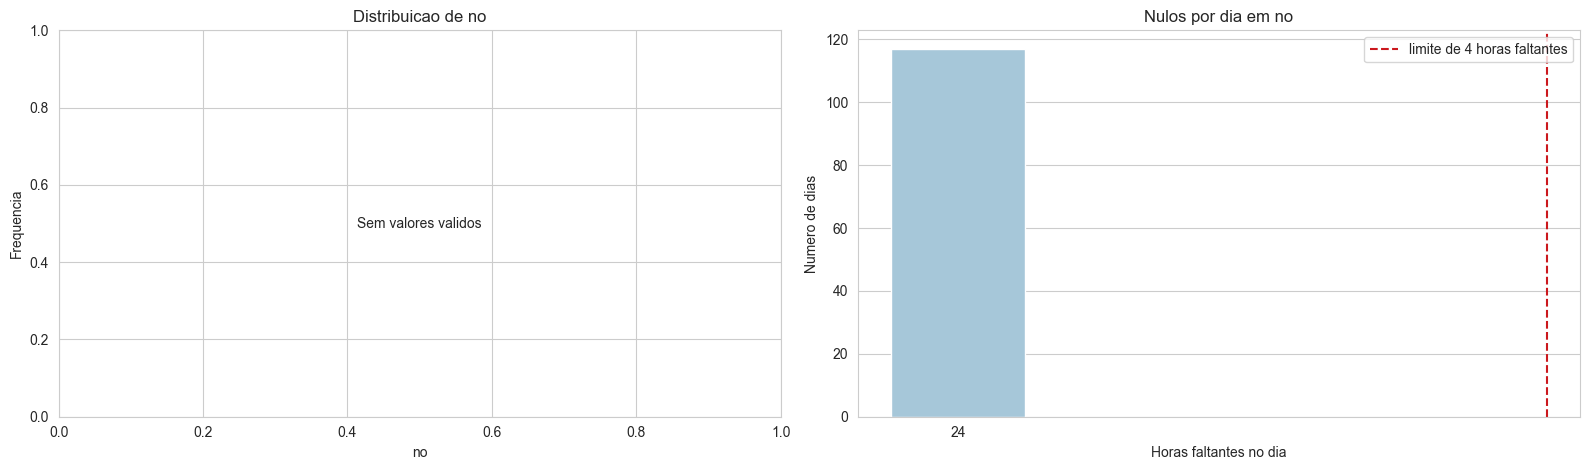

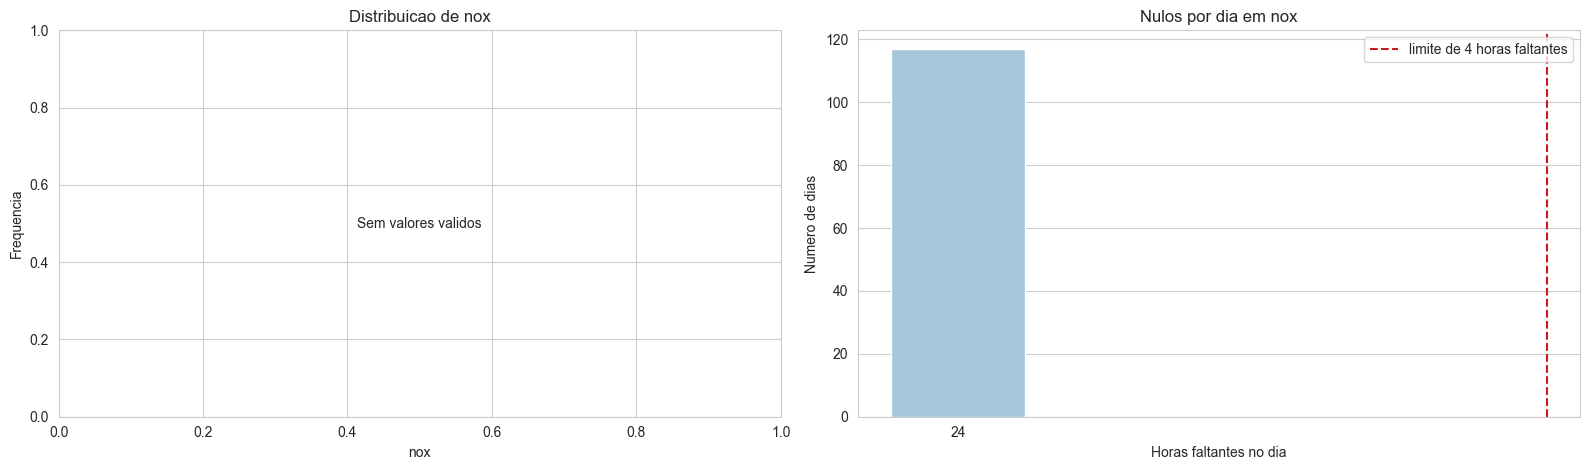

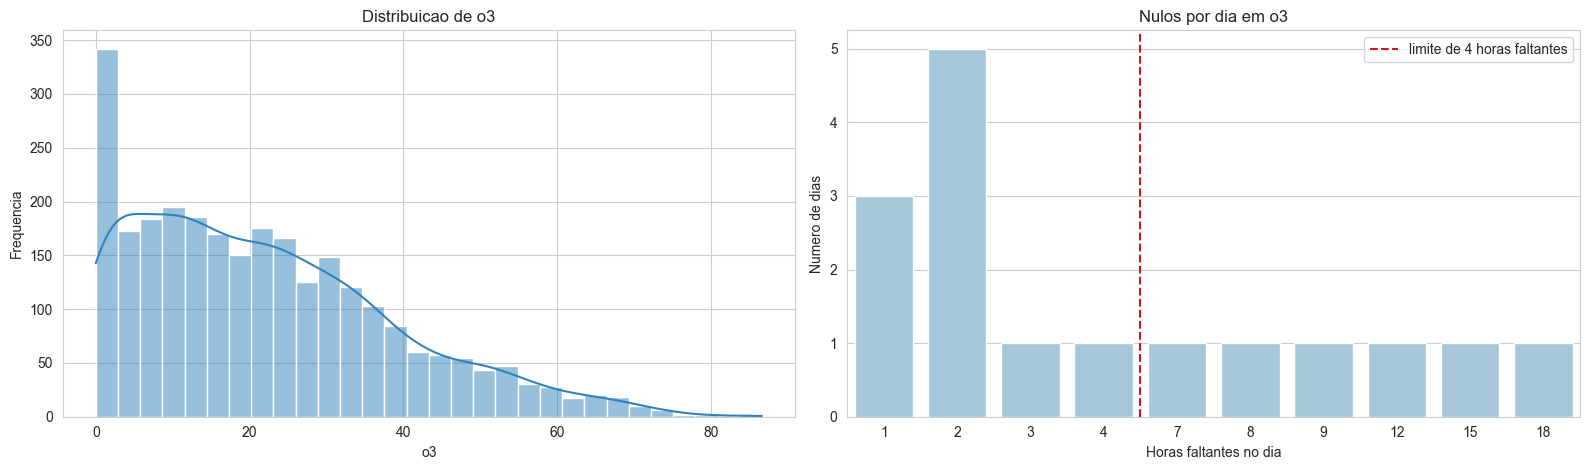

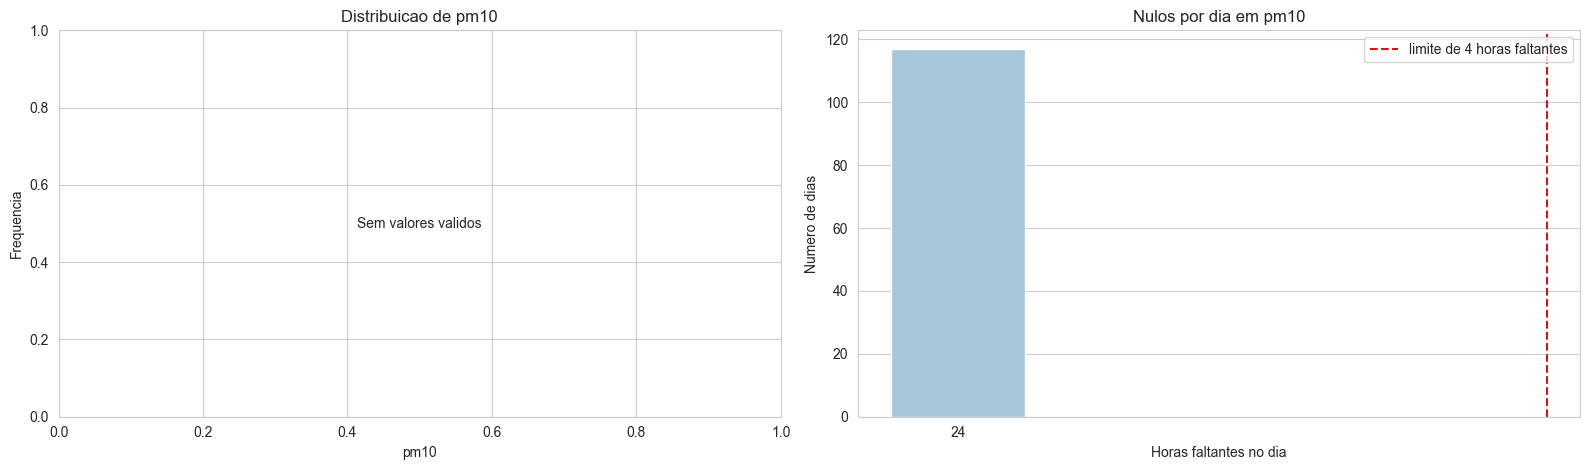

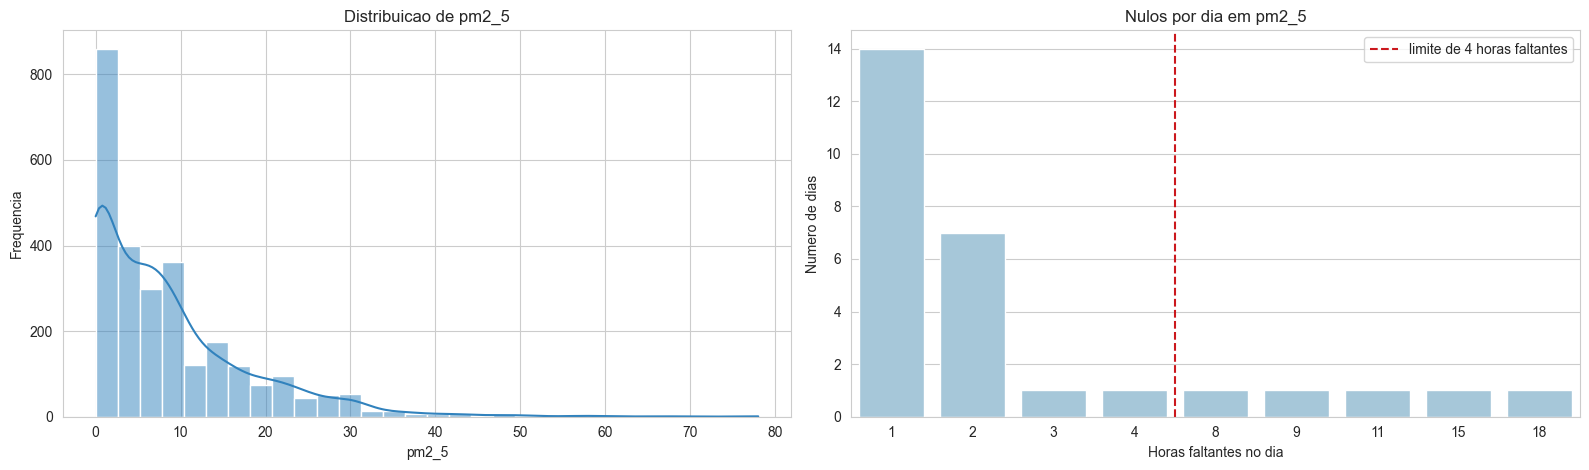

In [11]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_copacabana_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a Unidade Móvel Copacabana tem uma base **boa do ponto de vista temporal e operacional**, com perfil típico de monitoramento de campanha. A série cobre um período curto, de `2016-08-02 17:30` a `2016-11-26 23:30`, sem duplicatas de horário e com estabilidade de nome e coordenadas. Ao mesmo tempo, há apenas `5` timestamps faltantes em `2791` esperados, o que mostra que a linha do tempo é bastante consistente dentro da janela observada. Assim, nesta unidade, o principal cuidado analítico não está no calendário da série, mas na disponibilidade desigual entre as variáveis monitoradas.

A leitura de missing por variável mostra uma separação forte de qualidade. `no`, `no2`, `nox` e `pm10` estão estruturalmente indisponíveis (`100%` de nulos) e, neste recorte, não devem ser tratados como séries analisáveis. Entre as variáveis disponíveis, `so2` é a mais crítica, com perda alta (`37,2%`), enquanto `co` (`6,4%`), `pm2_5` (`2,7%`), `o3` (`2,4%`), `temp` (`2,1%`), `ur` (`1,7%`) e `chuva` (`1,6%`) apresentam cobertura melhor. Isso torna a unidade especialmente interessante para análises de `co`, `o3` e `pm2_5`, mas com cautela maior para `so2`.

As distribuições reforçam que a unidade monitora processos heterogêneos em um conjunto mais enxuto de variáveis. Entre as meteorológicas, `chuva` segue fortemente concentrada em zero e muito assimétrica, enquanto `temp` e `ur` apresentam comportamento mais estável. Entre os poluentes efetivamente disponíveis, `co`, `o3`, `pm2_5` e `so2` mostram **assimetria à direita**, indicando predominância de valores usuais com alguns episódios elevados. Em particular, `co` apresenta assimetria forte, `pm2_5` tem dispersão relevante mesmo com média baixa, e `o3` aparece com nível central moderado. Isso sugere que a unidade pode capturar eventos pontuais de poluição com boa sensibilidade, mesmo em um período curto.

A distribuição diária de nulos também ajuda a separar o que é lacuna curta do que é indisponibilidade estrutural. `chuva`, `temp`, `ur`, `o3` e `pm2_5` concentram muitos dias completos e, quando há falhas, elas costumam ser curtas, o que favorece estratégias simples de imputação local. `co` chama atenção por um comportamento ainda mais favorável: poucos dias totalmente completos, mas uma concentração muito alta de dias com apenas `1` a `4` horas faltantes, o que o torna um bom candidato a preenchimento pontual. `so2`, por outro lado, combina poucos dias completos com muitos dias severamente incompletos, o que exige bem mais cautela. Já `no`, `no2`, `nox` e `pm10` não apresentam um problema de preenchimento pontual: essas séries estão estruturalmente ausentes na unidade.

Em síntese, a Unidade Móvel Copacabana parece **útil como plataforma de monitoramento de campanha**, porque a base é temporalmente consistente, os metadados são estáveis e várias variáveis-chave têm cobertura suficiente para análise. O principal limite analítico está no conjunto incompleto de sensores e na forte incompletude de `so2`: `no`, `no2`, `nox` e `pm10` devem ser excluídos ou marcados como indisponíveis, `so2` exige maior controle de qualidade, e `co`, `o3`, `pm2_5`, `temp`, `ur` e `chuva` podem seguir com boa utilidade para as próximas etapas da EDA. Isso deixa claro que, nesta unidade, a confiabilidade é razoável no nível da base, mas a capacidade analítica fica concentrada em um subconjunto específico de variáveis e em um intervalo temporal curto.